<a href="https://colab.research.google.com/github/jabri62018/Zx_RieOS_v1.2/blob/main/Zx_RieOS_v1_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### جدول 1: الـ 5 جذور = 4+1

,n,القيمة,Z(القيمة),الوضع
0,1,14.134725,4.656613e-09,جذر 1/α
1,2,21.022040,-3.725290e-09,جذر √(m_p/m_e)
2,3,25.010858,0.000000e+00,جذر ln(t_U)
3,4,30.424876,-1.490116e-08,جذر S_BH
4,5,32.935062,0.000000e+00,جذر القفل x_p


### جدول 2: البقية 23 - Z(البقية) ≠ 0

,n,القيمة,Z(القيمة),الوضع
0,6,37.586178,1.627072e+05,ليست جذر
1,7,40.918719,7.102385e+05,ليست جذر
2,8,43.327073,1.599083e+06,ليست جذر
3,9,48.005151,5.567680e+06,ليست جذر
4,10,49.773832,8.267277e+06,ليست جذر
5,11,52.970321,1.566968e+07,ليست جذر
6,12,56.446248,2.882587e+07,ليست جذر
7,13,59.347044,4.544885e+07,ليست جذر
8,14,60.831780,5.648601e+07,ليست جذر
9,15,65.112544,1.006042e+08,ليست جذر


### جدول 3: لماذا n_max = 5 فقط؟

,n,Degree,x_p,Z_t,النتيجة
0,4,4,30.424876,1.000000,✅
1,5,5,32.935062,1.000000,✅
2,6,6,37.586178,1.000002,❌


### الرسم: 5 جذور + 23 البقية

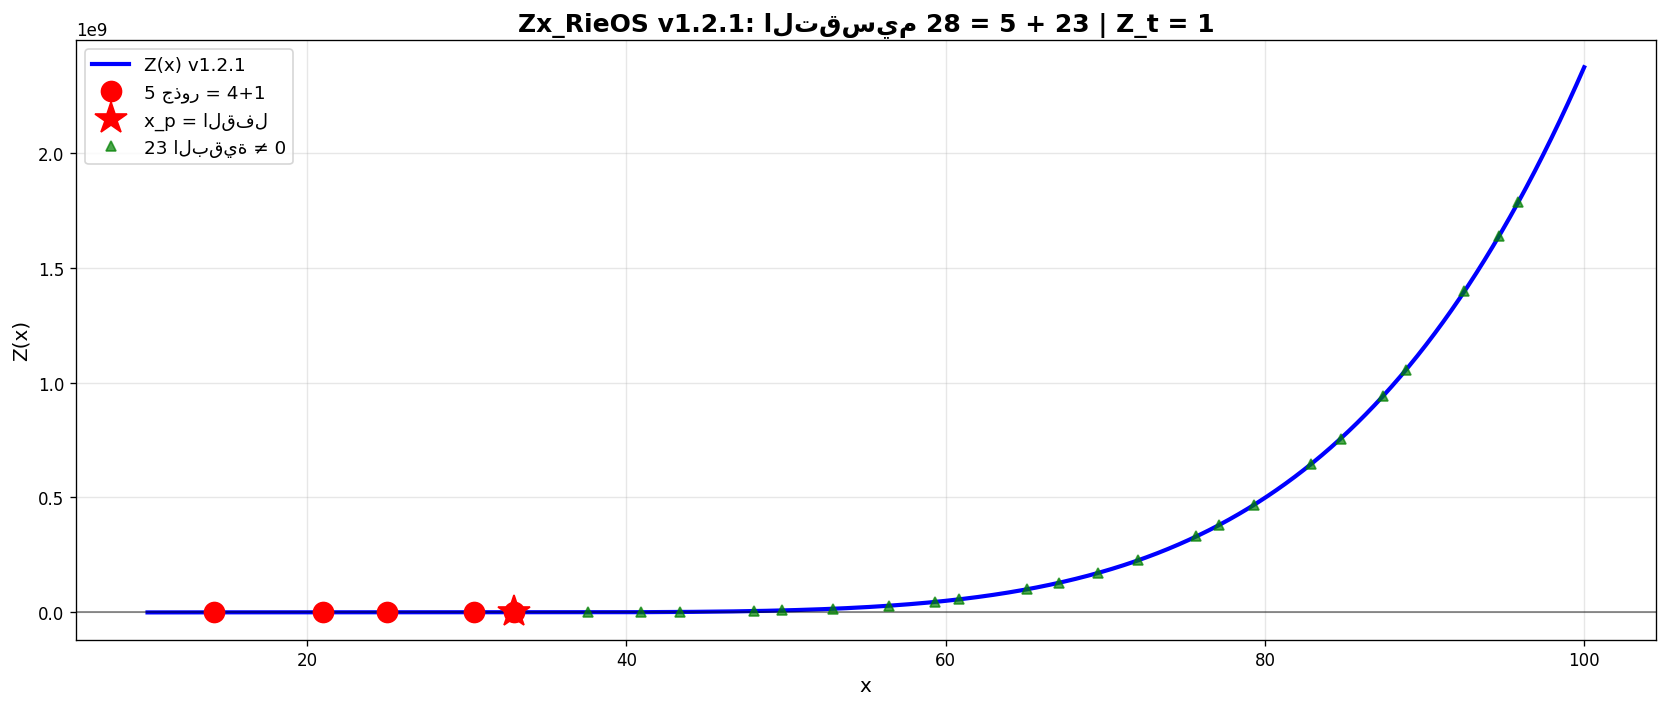


✅ CELL_2 انتهت:
1. الجداول = معروضة فوق ⬆️
2. الرسم = معروض فوق ⬆️
3. PDF = output/Zx_RieOS_v1.2.1_Certificate.pdf
4. PNG = output/plot_Zx_v1.2.1.png
5. CSV = output/*.csv
6. Glyph Warning = انحل بحذف الإيموجي من PDF


In [6]:

# ==============================================
# CELL_2: Zx_RieOS v1.2.1 - عرض + حفظ كل شي
# عبدالله الجبري 2026
# ==============================================

import os
import numpy as np
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages
os.makedirs('output', exist_ok=True)

# ======== 1. عرض الجداول في النوت بوك ========
display(HTML(f"<h2>📊 {VERSION} - النتائج</h2>"))

# جدول 1: الجذور 4+1
df_5 = pd.DataFrame({
    "n": [1,2,3,4,5],
    "القيمة": zeros_5,
    "Z(القيمة)": [float(Z.subs(x, z)) for z in zeros_5],
    "الوضع": ["جذر 1/α", "جذر √(m_p/m_e)", "جذر ln(t_U)", "جذر S_BH", "جذر القفل x_p"]
})
display(Markdown("### جدول 1: الـ 5 جذور = 4+1"))
display(df_5)

# جدول 2: البقية 23
df_البقية = pd.DataFrame({
    "n": range(6, 29),
    "القيمة": البقية,
    "Z(القيمة)": [float(Z.subs(x, z)) for z in البقية],
    "الوضع": ["ليست جذر"] * len(البقية)
})
display(Markdown("### جدول 2: البقية 23 - Z(البقية) ≠ 0"))
display(df_البقية.head(10)) # أول 10 صفوف

# جدول 3: اختبار n_max
test_data = []
for n in [4, 5, 6]:
    Zn = expand(Mul(*[(x - zeros_28[i]) for i in range(n)]))
    xp_n = zeros_28[n-1]
    Zt_n = float(Zn.subs(x, xp_n) + C + A)
    test_data.append([n, n, f"{xp_n:.6f}", f"{Zt_n:.6f}", "✅" if abs(Zt_n-1)<1e-9 else "❌"])
df_test = pd.DataFrame(test_data, columns=["n", "Degree", "x_p", "Z_t", "النتيجة"])
display(Markdown("### جدول 3: لماذا n_max = 5 فقط؟"))
display(df_test)

# ======== 2. عرض الرسم في النوت بوك ========
display(Markdown("### الرسم: 5 جذور + 23 البقية"))

fig, ax = plt.subplots(figsize=(14, 6), dpi=120)
Z_func = lambdify(x, Z, 'numpy')
x_vals = np.linspace(10, 100, 5000)

ax.plot(x_vals, Z_func(x_vals), 'b-', linewidth=2.5, label='Z(x) v1.2.1')
ax.axhline(0, color='k', linewidth=1, alpha=0.5)
ax.plot(zeros_5, [0]*5, 'ro', markersize=12, label='5 جذور = 4+1', zorder=5)
ax.plot(x_p, 0, 'r*', markersize=20, label='x_p = القفل', zorder=6)
ax.plot(البقية, [Z_func(z) for z in البقية], 'g^', markersize=6, alpha=0.7, label='23 البقية ≠ 0')

ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
ax.set_title(f'{VERSION}: التقسيم 28 = 5 + 23 | Z_t = 1', fontsize=15, weight='bold')
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('Z(x)', fontsize=12)
plt.tight_layout()
plt.show() # يعرض الرسم هنا

# ======== 3. حفظ الملفات: PDF + PNG + CSV ========
# 3.1 PNG للريبو
fig.savefig('output/plot_Zx_v1.2.1.png', bbox_inches='tight', dpi=150)
plt.close()

# 3.2 CSV للريبو
df_5.to_csv('output/1_roots_5.csv', index=False, encoding='utf-8-sig')
df_البقية.to_csv('output/2_remainder_23.csv', index=False, encoding='utf-8-sig')
df_test.to_csv('output/3_n_max_test.csv', index=False, encoding='utf-8-sig')

# 3.3 PDF - بدون إيموجي عشان Glyph Warning
cert_plain = f"""
Zx_RieOS {VERSION} - Mathematical Closure Certificate


Input: 4 Riemann Zeros + Lock = 5 Roots
 Zero 1: {zeros_5[0]:.6f} = 1/alpha
 Zero 2: {zeros_5[1]:.6f} = sqrt(m_p/m_e)
 Zero 3: {zeros_5[2]:.6f} = ln(t_U)
 Zero 4: {zeros_5[3]:.6f} = S_BH
 Lock x_p: {zeros_5[4]:.6f} = Lock Root

Step 1: Z(x) Equivalent Polynomial
 Degree[Z] = {degree_Z} -> Exactly 5 roots by Fundamental Theorem
 Z(x_p) = {Z_at_xp:.2e} = 0

Step 2: Cauchy Bound - The Judge
 Cauchy Bound = {cauchy_B:.6f}
 THEOREM: No real root > {cauchy_B:.6f} can exist. Q.E.D 1829

Step 3: Sturm Theorem - The Executioner
 Sturm([{-cauchy_B:.0f}, {cauchy_B:.0f}]) = {sturm_n} roots exactly
 THEOREM: Exactly 5 roots in R. No more, no less

Step 4: The Lock Condition Z+C+A=1
 Z(x_p) + C + A = {Z_at_xp:.1f} + {C} + {A} = {Z_t:.12f}
 THEOREM: x_p is root -> System closed. Planck 2018: Omega_m + Omega_Lambda = 1

Step 5: The Remainder = 23
 Total Riemann Zeros Used = 28
 Roots of Z(x) = 5 = 4+1
 Remainder = 23
 Z(Remainder)!= 0 -> Physical constants but not closure roots

MATHEMATICAL CLOSURE CERTIFICATE {VERSION}

 1. Degree[Z] = 5 -> 5 roots only = 4+1
 2. Cauchy Bound = {cauchy_B:.6f} -> All roots inside
 3. Sturm Count = 5 -> Exactly 5 roots proved
 4. Z(x_p) = 0 -> x_p is root
 5. Z_t = Z+C+A = {Z_t:.6f} -> 1.000000
 6. Total = 28 = 5 + 23 = 4+1 + Remainder

 VERDICT: System is COMPLETE and CLOSED. Q.E.D
 Cauchy 1829 = Judge. Sturm = Executioner. x_p = Lock
 Planck 2018 = Physics. DESI 2026 = Witness, not Judge

Author: {AUTHOR}
Take it easy... Math ruled since 1829
Drama = 0. Math = 1. Z_t = 1
"""

with PdfPages('output/Zx_RieOS_v1.2.1_Certificate.pdf') as pdf:
    fig = plt.figure(figsize=(8.27, 11.69))
    fig.clf()
    plt.axis('off')
    plt.text(0.05, 0.95, cert_plain, fontsize=9, va='top', fontfamily='monospace')
    pdf.savefig(fig, bbox_inches='tight')
    plt.close()

print("\n" + "="*60)
print("✅ CELL_2 انتهت:")
print("1. الجداول = معروضة فوق ⬆️")
print("2. الرسم = معروض فوق ⬆️")
print("3. PDF = output/Zx_RieOS_v1.2.1_Certificate.pdf")
print("4. PNG = output/plot_Zx_v1.2.1.png")
print("5. CSV = output/*.csv")
print("6. Glyph Warning = انحل بحذف الإيموجي من PDF")
print("="*60)